In [9]:
import plotly.express as px
import pandas as pd
import pyodbc

In [10]:
dados_conexao = (
'Driver={ODBC Driver 17 for SQL Server};'
'Server=DSN1221248770;'
'Database=BDFazenda;'
'Trusted_Connection=yes;'
)
conexao = pyodbc.connect(dados_conexao)
print("Conexão OK")

Conexão OK


In [17]:
data_venda = 'SELECT * FROM VW_resumo_vendas'

In [18]:
df_resumo_venda = pd.read_sql(data_venda, conexao)

C:\Users\Aluno\AppData\Local\Temp\ipykernel_9928\2518593912.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_resumo_venda = pd.read_sql(data_venda, conexao)


In [19]:
display(df_resumo_venda)

,id_venda,data_venda,item,valor_venda,nome_filial,estado
0,1,2021-01-01,Milho,52686.6052,Fazenda Pedra Branca,Mato Grosso
1,2,2021-01-01,Sorgo,88440.9514,Fazenda Rio Pequeno,Mato Grosso
2,3,2021-01-01,Soja,15670.0720,Fazenda Rio Verde,Goiás
3,4,2021-01-01,Soja,279.2895,Fazenda Rio Verde,Goiás
4,5,2021-01-01,Milho,106128.1824,Fazenda Monte Azul,Mato Grosso do Sul
...,...,...,...,...,...,...
9995,9996,2021-12-31,Milho,11639.5124,Fazenda Rio Pequeno,Mato Grosso
9996,9997,2021-12-31,Soja,49068.8463,Fazenda Rio Verde,Goiás
9997,9998,2021-12-31,Milho,11880.8474,Fazenda Rio Verde,Goiás
9998,9999,2021-12-31,Milho,5413.5251,Fazenda Campo Belo,Mato Grosso


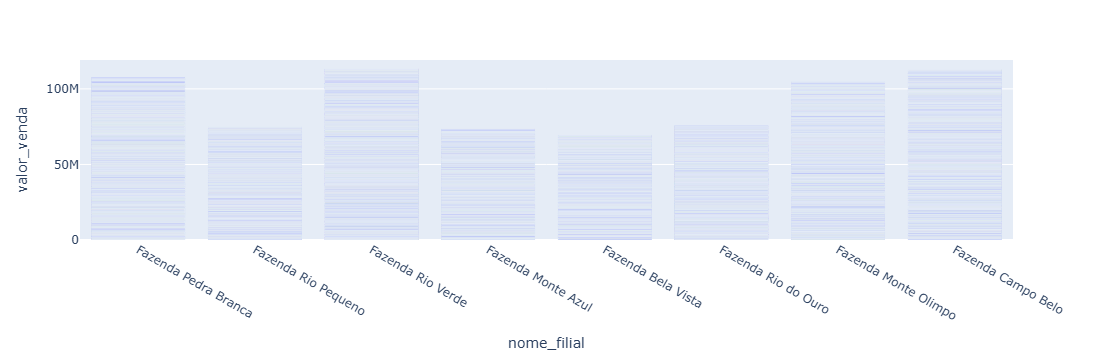

In [20]:
coluna_1 = px.bar(df_resumo_venda, x = 'nome_filial', y= 'valor_venda')
coluna_1.show()

In [21]:
df_venda_agrupado = df_resumo_venda.groupby('nome_filial')['valor_venda'].sum().reset_index()
display(df_venda_agrupado)

,nome_filial,valor_venda
0,Fazenda Bela Vista,6.947902e+07
1,Fazenda Campo Belo,1.126645e+08
2,Fazenda Monte Azul,7.337104e+07
3,Fazenda Monte Olimpo,1.047748e+08
4,Fazenda Pedra Branca,1.079293e+08
5,Fazenda Rio Pequeno,7.485081e+07
6,Fazenda Rio Verde,1.131542e+08
7,Fazenda Rio do Ouro,7.568621e+07


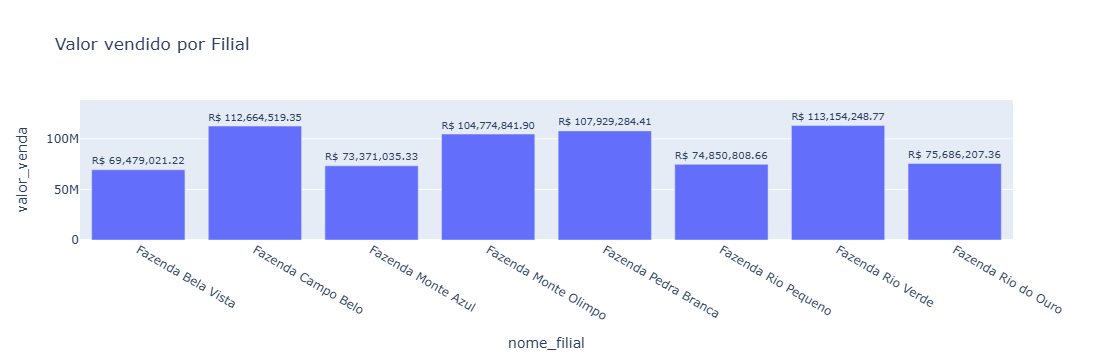

In [25]:
coluna_2 = px.bar(df_venda_agrupado, x='nome_filial', y= 'valor_venda', title = 'Valor vendido por Filial', text = 'valor_venda')
coluna_2.update_traces(texttemplate = 'R$ %{text:,.2f}', #formata o valor_venda considerando real (R$) com duas casas decimais(2.f)
                       textposition = 'outside') #posiciona o valor_venda fora da coluna(outside)

coluna_2.show()

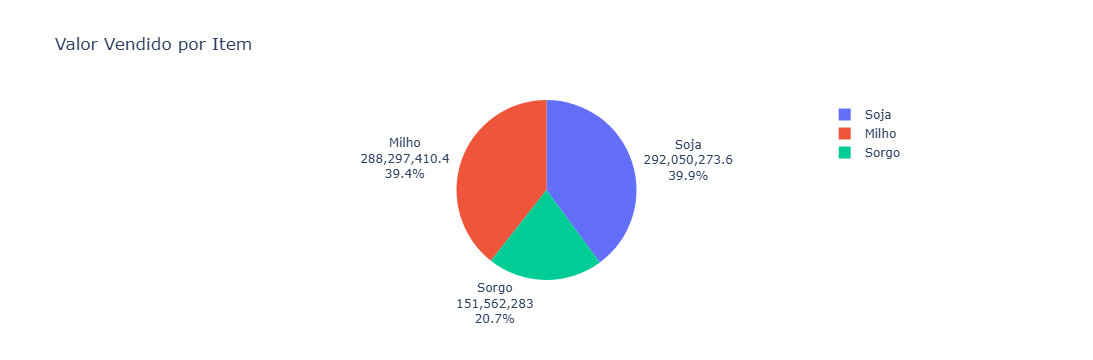

In [29]:
pizza_1 = px.pie(df_resumo_venda, names = 'item', values = 'valor_venda', title = 'Valor Vendido por Item')
pizza_1.update_traces(textinfo = 'percent+label+value', textposition = 'outside')
pizza_1.show()